# IMU Resampling to 60 Hz

This notebook resamples the labeled IMU CSV files from their original (irregular) sample rate to 60 Hz.

**Input:** `IMU_devX_labeled.csv` (from the labeling notebook)

**Output:** `IMU_devX_labeled_60Hz.csv`

**Steps:**
1. Interpolate signals onto a regular time grid (removes timestamp irregularities)
2. Resample to exactly 60 Hz
3. Re-assign FoG labels (majority vote per new sample)
4. Visual verification

## 1. Imports

In [53]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

## 2. Parameters

In [55]:
import os

TARGET_FS = 60  # Hz — target sample rate for the model
DEVICES   = ['dev2', 'dev3', 'dev5', 'dev6', 'dev7']

# Must match the SESSION_NAME used in fog_labeling_from_eaf.ipynb
# e.g. 'task_stop_FOG002' — just change PATH_EAF name here and it is extracted automatically
PATH_EAF     = 'task_obstacles_FOG003.eaf'
SESSION_NAME = os.path.splitext(os.path.basename(PATH_EAF))[0]
print(f'Session: {SESSION_NAME}')
print(f'Input files : IMU_devX_{SESSION_NAME}_labeled.csv')
print(f'Output files: IMU_devX_{SESSION_NAME}_labeled_60Hz.csv')

# Original sample rates from DataCheck (recording_data.h5 -> DataCheck/stream_detail_4_WIMU_MK3)
# Note: timestamps are irregular (jitter std ~11ms ~ 0.9x mean period) -> interpolation is mandatory
ORIGINAL_FS = {
    'dev2': 80.5,  # Hz
    'dev3': 83.6,  # Hz
    'dev5': 81.4,  # Hz
    'dev6': 79.0,  # Hz — update once confirmed
    'dev7': 81.8,  # Hz — update once confirmed
}
# Max gaps (from DataCheck): dev2=0.141s, dev3=0.132s, dev5=0.145s
# These gaps will be filled by linear interpolation

# Columns to resample (continuous signals)
SIGNAL_COLS = ['acc_x', 'acc_y', 'acc_z', 'quat_w', 'quat_x', 'quat_y', 'quat_z']

print('\nOriginal sample rates:')
for dev, fs in ORIGINAL_FS.items():
    print(f'  {dev}: {fs} Hz -> resampling to {TARGET_FS} Hz')

Session: task_obstacles_FOG003
Input files : IMU_devX_task_obstacles_FOG003_labeled.csv
Output files: IMU_devX_task_obstacles_FOG003_labeled_60Hz.csv

Original sample rates:
  dev2: 80.5 Hz -> resampling to 60 Hz
  dev3: 83.6 Hz -> resampling to 60 Hz
  dev5: 81.4 Hz -> resampling to 60 Hz
  dev6: 79.0 Hz -> resampling to 60 Hz
  dev7: 81.8 Hz -> resampling to 60 Hz


## 4. Resampling function

In [56]:
def resample_to_60hz(df, target_fs=60, signal_cols=SIGNAL_COLS):
    """
    Resample an IMU DataFrame to a fixed sample rate.
    
    - Continuous signals: linear interpolation onto regular grid
    - FoG label: majority vote (1 if any FoG sample in the window)
    """
    t_orig = df['timestamp_lsl'].values
    t_start = t_orig[0]
    t_end   = t_orig[-1]
    
    # New regular time grid at target_fs
    t_new = np.arange(t_start, t_end, 1.0 / target_fs)
    
    df_resampled = pd.DataFrame()
    df_resampled['timestamp_lsl'] = t_new
    
    # Interpolate continuous signals
    for col in signal_cols:
        interp = interp1d(t_orig, df[col].values, kind='linear', bounds_error=False, fill_value='extrapolate')
        df_resampled[col] = interp(t_new)
    
    # FoG label: 1 if there is at least one FoG sample in the interpolation window
    labels_orig = df['fog_label'].values
    new_labels  = np.zeros(len(t_new), dtype=int)
    
    for i, t in enumerate(t_new):
        # Find original samples within +/- half a period
        half_period = 0.5 / target_fs
        mask = (t_orig >= t - half_period) & (t_orig < t + half_period)
        if mask.sum() > 0 and labels_orig[mask].max() == 1:
            new_labels[i] = 1
    
    df_resampled['fog_label'] = new_labels
    
    return df_resampled

## 5. Resample all devices

In [57]:
for dev in DEVICES:
    df_orig = pd.read_csv(f'IMU_{dev}_{SESSION_NAME}_labeled.csv')
    
    df_60hz = resample_to_60hz(df_orig, target_fs=TARGET_FS)
    
    output_path = f'IMU_{dev}_{SESSION_NAME}_labeled_60Hz.csv'
    df_60hz.to_csv(output_path, index=False)
    
    duration_orig  = df_orig['timestamp_lsl'].iloc[-1] - df_orig['timestamp_lsl'].iloc[0]
    expected_samples = int(duration_orig * TARGET_FS)
    
    print(f"{dev}")
    print(f"  Original  : {len(df_orig)} samples")
    print(f"  Resampled : {len(df_60hz)} samples (expected ~{expected_samples})")
    print(f"  FoG label : {df_60hz['fog_label'].sum()} samples ({100*df_60hz['fog_label'].mean():.1f}%)")
    print(f"  Saved to  : {output_path}\n")

dev2
  Original  : 60474 samples
  Resampled : 45085 samples (expected ~45084)
  FoG label : 188 samples (0.4%)
  Saved to  : IMU_dev2_task_obstacles_FOG003_labeled_60Hz.csv

dev3
  Original  : 62588 samples
  Resampled : 45084 samples (expected ~45083)
  FoG label : 207 samples (0.5%)
  Saved to  : IMU_dev3_task_obstacles_FOG003_labeled_60Hz.csv

dev5
  Original  : 61071 samples
  Resampled : 45084 samples (expected ~45083)
  FoG label : 221 samples (0.5%)
  Saved to  : IMU_dev5_task_obstacles_FOG003_labeled_60Hz.csv

dev6
  Original  : 59396 samples
  Resampled : 45083 samples (expected ~45082)
  FoG label : 202 samples (0.4%)
  Saved to  : IMU_dev6_task_obstacles_FOG003_labeled_60Hz.csv

dev7
  Original  : 61299 samples
  Resampled : 45086 samples (expected ~45085)
  FoG label : 208 samples (0.5%)
  Saved to  : IMU_dev7_task_obstacles_FOG003_labeled_60Hz.csv



## 6. Visual verification
Compare original vs resampled signal to check interpolation quality.

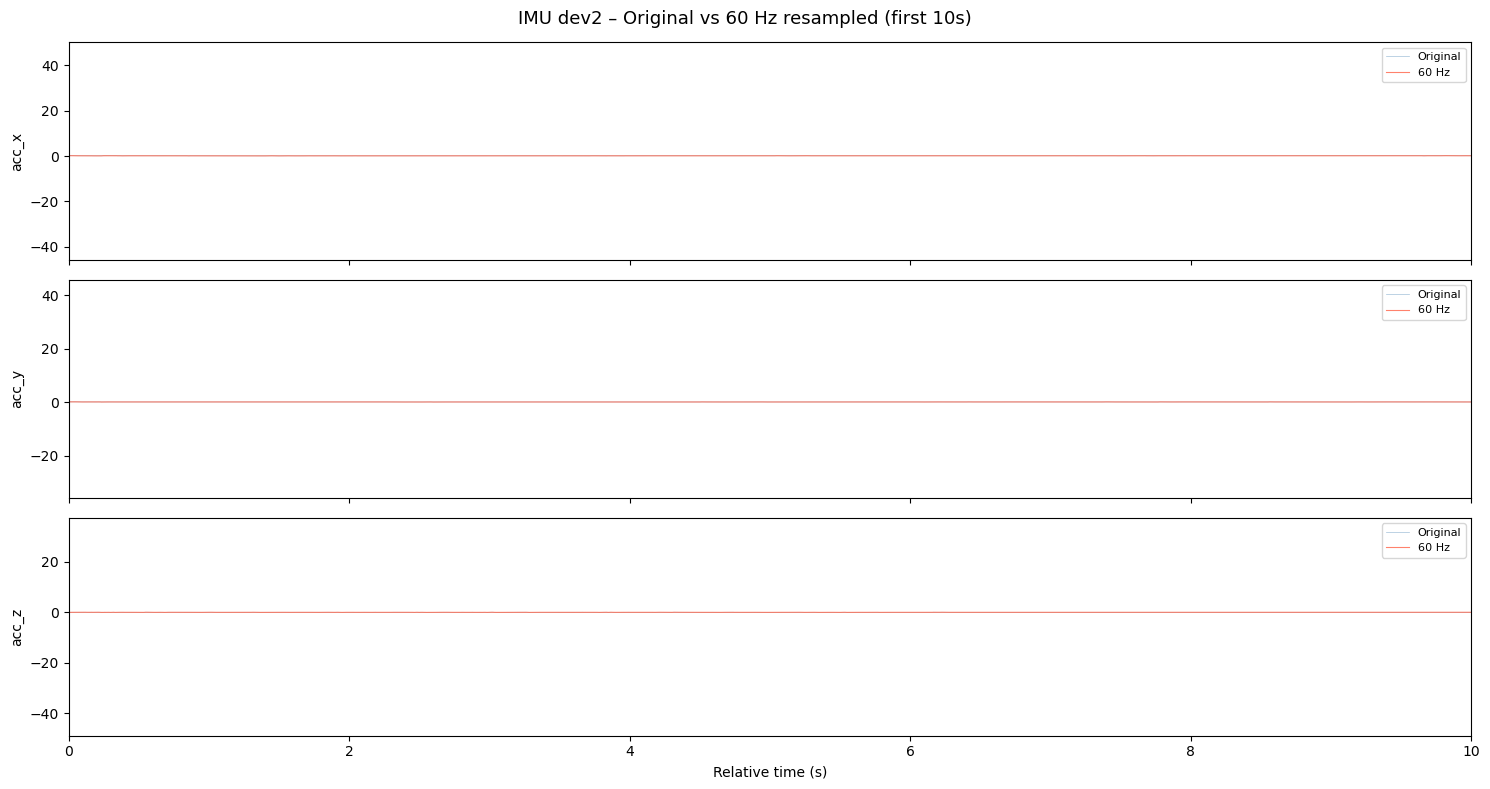

In [58]:
DEV_TO_PLOT = 'dev2'  # change here to inspect another device
ZOOM_SEC    = 10      # zoom window in seconds to inspect interpolation

df_orig  = pd.read_csv(f'IMU_{DEV_TO_PLOT}_{SESSION_NAME}_labeled.csv')
df_60hz  = pd.read_csv(f'IMU_{DEV_TO_PLOT}_{SESSION_NAME}_labeled_60Hz.csv')

t_orig = df_orig['timestamp_lsl'] - df_orig['timestamp_lsl'].iloc[0]
t_new  = df_60hz['timestamp_lsl'] - df_60hz['timestamp_lsl'].iloc[0]

fig, axes = plt.subplots(3, 1, figsize=(15, 8), sharex=True)

for ax, col in zip(axes, ['acc_x', 'acc_y', 'acc_z']):
    ax.plot(t_orig, df_orig[col], alpha=0.5, linewidth=0.5, label='Original', color='steelblue')
    ax.plot(t_new,  df_60hz[col], alpha=0.8, linewidth=0.8, label='60 Hz',    color='tomato')
    ax.set_ylabel(col)
    ax.legend(loc='upper right', fontsize=8)
    # Highlight FoG zones
    ax.fill_between(t_new, ax.get_ylim()[0], ax.get_ylim()[1],
                    where=df_60hz['fog_label']==1, alpha=0.15, color='red')

axes[-1].set_xlabel('Relative time (s)')
axes[-1].set_xlim(0, ZOOM_SEC)  # zoom on first N seconds
plt.suptitle(f'IMU {DEV_TO_PLOT} – Original vs 60 Hz resampled (first {ZOOM_SEC}s)', fontsize=13)
plt.tight_layout()
plt.savefig(f'IMU_{DEV_TO_PLOT}_{SESSION_NAME}_resample_check.png', dpi=150)
plt.show()

## 7. Final check – sample rate of resampled files

In [59]:
print("Verifying sample rates of resampled files:")
for dev in DEVICES:
    df = pd.read_csv(f'IMU_{dev}_{SESSION_NAME}_labeled_60Hz.csv')
    dt = np.diff(df['timestamp_lsl'].values)
    fs = 1.0 / np.mean(dt)
    print(f"  {dev} → {fs:.2f} Hz ✓" if abs(fs - TARGET_FS) < 0.1 else f"  {dev} → {fs:.2f} Hz ✗ (check!)")

Verifying sample rates of resampled files:
  dev2 → 60.00 Hz ✓
  dev3 → 60.00 Hz ✓
  dev5 → 60.00 Hz ✓
  dev6 → 60.00 Hz ✓
  dev7 → 60.00 Hz ✓


## 8. Concatenate csv files (optional)

In [38]:
import pandas as pd
import glob

device = 'dev7'

# Charger tous les CSV de ce device
files = glob.glob(f'IMU_{device}_task_*_labeled_60Hz.csv')

dfs = []
for f in files:
    df = pd.read_csv(f)
    # Extraire le nom de la tâche depuis le nom du fichier
    task_name = f.replace(f'IMU_{device}_', '').replace('_labeled_60Hz.csv', '')
    df['task_name'] = task_name
    dfs.append(df)

combined = pd.concat(dfs, ignore_index=True)
combined.to_csv(f'IMU_{device}_all_tasks.csv', index=False)
print(f"{len(dfs)} fichiers concatenés → {len(combined)} samples")

4 fichiers concatenés → 208571 samples


In [39]:
df = pd.read_csv('IMU_dev7_all_tasks.csv')

fog_samples = df['fog_label'].sum()
total       = len(df)
non_fog     = total - fog_samples

print(f"Total samples : {total}")
print(f"FOG           : {fog_samples} ({100*fog_samples/total:.1f}%)")
print(f"Non-FOG       : {non_fog} ({100*non_fog/total:.1f}%)")

Total samples : 208571
FOG           : 925 (0.4%)
Non-FOG       : 207646 (99.6%)


In [40]:
print(df.groupby('task_name')['fog_label'].agg(['sum', 'count'])
        .rename(columns={'sum': 'fog_samples', 'count': 'total'})
        .assign(fog_pct=lambda x: (100*x['fog_samples']/x['total']).round(1)))

                            fog_samples  total  fog_pct
task_name                                              
task_circuit8_FOG002                623  63918      1.0
task_narrowCorridor_FOG002          302  59649      0.5
task_obstacles_FOG002                 0  69005      0.0
task_stop_FOG002                      0  15999      0.0
